In [57]:
!pip install nflreadpy

In [58]:
import nflreadpy as nfl
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

seasons = [2021, 2022, 2023, 2024]
pbp_data = nfl.load_pbp(seasons)

if not isinstance(pbp_data, pd.DataFrame):
    pbp_df = pbp_data.to_pandas()
else:
    pbp_df = pbp_data.copy()

print(f"Successfully loaded {len(pbp_df):,} plays.")
display(pbp_df.head(3))

Successfully loaded 198,513 plays.


,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
0,1.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,None,None,None,...,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,40.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,55.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,0.0,1.0,-1.399805,NaN,NaN,NaN,NaN,NaN,0.491433,-49.143299


In [60]:
# 1. Load Data
part_data = nfl.load_participation(seasons)

part_df = part_data.to_pandas()

# 2. Merge columns
pbp_df = pbp_df.merge(
    part_df[['nflverse_game_id', 'play_id', 'offense_personnel']],
    left_on=['game_id', 'play_id'],
    right_on=['nflverse_game_id', 'play_id'],
    how='inner'
)

# 3. Filter down to true offensive plays
valid_plays = ['run', 'pass']
model_df = pbp_df[pbp_df['play_type'].isin(valid_plays)].copy()

# 4. Remove QB spikes and kneel-downs (not true playcalls)
model_df = model_df[(model_df['qb_kneel'] == 0) & (model_df['qb_spike'] == 0)]

# 5. Drop rows missing our core predictive features
core_features = ['down', 'ydstogo', 'yardline_100', 'score_differential', 'half_seconds_remaining', 'offense_personnel', 'no_huddle']
model_df = model_df.dropna(subset=core_features)

# 6. Extract personnel counts from strings like "1 RB, 1 TE, 3 WR"
model_df['rb_count'] = model_df['offense_personnel'].str.extract(r'(\d+) RB').fillna(0).astype(int)
model_df['te_count'] = model_df['offense_personnel'].str.extract(r'(\d+) TE').fillna(0).astype(int)
model_df['wr_count'] = model_df['offense_personnel'].str.extract(r'(\d+) WR').fillna(0).astype(int)

# 7. Create the target variable: 1 if pass, 0 if run
model_df['is_pass'] = (model_df['play_type'] == 'pass').astype(int)

print(f"Plays remaining for model training: {len(model_df):,}")
display(model_df[['play_type', 'is_pass', 'down', 'ydstogo', 'offense_personnel', 'rb_count', 'te_count', 'wr_count']].head(3))

Plays remaining for model training: 141,288


,play_type,is_pass,down,ydstogo,offense_personnel,rb_count,te_count,wr_count
2,run,0,1.0,10.0,"1 RB, 2 TE, 2 WR",1,2,2
3,pass,1,2.0,13.0,"1 RB, 2 TE, 2 WR",1,2,2
4,pass,1,3.0,10.0,"1 RB, 1 TE, 3 WR",1,1,3


In [61]:
# 1. Engineer the new score-time urgency ratio (adding 1 to prevent division by zero)
model_df['score_time_ratio'] = model_df['score_differential'] / (model_df['half_seconds_remaining'] + 1)

# 2. Update the features list with the new structural and engineered columns
features = [
    'down', 'ydstogo', 'yardline_100', 'score_differential',
    'half_seconds_remaining', 'rb_count', 'te_count', 'wr_count', 'no_huddle', 'score_time_ratio'
]

X = model_df[features]
y = model_df['is_pass']

# 3. Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Gradient Boosting Model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

print("Training the upgraded XGBoost model...")
xgb_model.fit(X_train, y_train)
print("Model training complete!")

Training the upgraded XGBoost model...
Model training complete!


In [62]:
# 1. Generate predictions on the holdout test set
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probability of a pass

# 2. Calculate Evaluation Metrics
acc = accuracy_score(y_test, y_pred)
loss = log_loss(y_test, y_pred_proba)

print(f"Accuracy: {acc:.2%}")
print(f"Log-Loss: {loss:.4f}")

# 3. Check Feature Importances
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nWhat the model relied on most:")
display(importance_df)

Accuracy: 69.60%
Log-Loss: 0.5688

What the model relied on most:


,Feature,Importance
7,wr_count,0.381223
0,down,0.184549
1,ydstogo,0.146775
9,score_time_ratio,0.125453
4,half_seconds_remaining,0.048870
8,no_huddle,0.028876
2,yardline_100,0.023607
5,rb_count,0.021219
6,te_count,0.020101
3,score_differential,0.019327


In [63]:
# 1. Load the 2025 season as our blind holdout set
test_data = nfl.load_pbp([2025])
test_part = nfl.load_participation([2025])

if not isinstance(test_data, pd.DataFrame):
    test_data = test_data.to_pandas()
    test_part = test_part.to_pandas()

# 2. Merge and filter the 2025 data exactly as we did for the training set
test_df = test_data.merge(
    test_part[['nflverse_game_id', 'play_id', 'offense_personnel']],
    left_on=['game_id', 'play_id'], right_on=['nflverse_game_id', 'play_id'], how='inner'
)

test_df = test_df[test_df['play_type'].isin(['run', 'pass'])]
test_df = test_df[(test_df['qb_kneel'] == 0) & (test_df['qb_spike'] == 0)]
test_df = test_df.dropna(subset=core_features).copy()

test_df['rb_count'] = test_df['offense_personnel'].str.extract(r'(\d+) RB').fillna(0).astype(int)
test_df['te_count'] = test_df['offense_personnel'].str.extract(r'(\d+) TE').fillna(0).astype(int)
test_df['wr_count'] = test_df['offense_personnel'].str.extract(r'(\d+) WR').fillna(0).astype(int)
test_df['is_pass'] = (test_df['play_type'] == 'pass').astype(int)

# NEW: Calculate the score-time ratio for the 2025 data so the model has it!
test_df['score_time_ratio'] = test_df['score_differential'] / (test_df['half_seconds_remaining'] + 1)

# 3. Generate predictions using the upgraded model
X_2025 = test_df[features]
test_df['pass_prob'] = xgb_model.predict_proba(X_2025)[:, 1]

# 4. Calculate predictability (Log-Loss) per team
team_predictability = []
for team in test_df['posteam'].unique():
    team_plays = test_df[test_df['posteam'] == team]
    team_loss = log_loss(team_plays['is_pass'], team_plays['pass_prob'])
    team_predictability.append({
        'Team': team,
        'Predictability_Score': team_loss,
        'Total_Plays': len(team_plays)
    })

predictability_df = pd.DataFrame(team_predictability).sort_values(by='Predictability_Score', ascending=True).reset_index(drop=True)

In [64]:
# 1. Create a mapping dictionary for the 2025 coaches
# You can fill in the remaining teams as needed for your specific analysis
coach_mapping = {
    'ARI': {'Head_Coach': 'Jonathan Gannon', 'Play_Caller': 'Drew Petzing'},
    'ATL': {'Head_Coach': 'Raheem Morris', 'Play_Caller': 'Zac Robinson'},
    'BAL': {'Head_Coach': 'John Harbaugh', 'Play_Caller': 'Todd Monken'},
    'BUF': {'Head_Coach': 'Sean McDermott', 'Play_Caller': 'Joe Brady'},
    'CAR': {'Head_Coach': 'Dave Canales', 'Play_Caller': 'Dave Canales'},
    'CHI': {'Head_Coach': 'Ben Johnson', 'Play_Caller': 'Ben Johnson'},
    'CIN': {'Head_Coach': 'Zac Taylor', 'Play_Caller': 'Zac Taylor'},
    'CLE': {'Head_Coach': 'Kevin Stefanski', 'Play_Caller': 'Kevin Stefanski'},
    'DAL': {'Head_Coach': 'Mike McCarthy', 'Play_Caller': 'Mike McCarthy'},
    'DEN': {'Head_Coach': 'Sean Payton', 'Play_Caller': 'Sean Payton'},
    'DET': {'Head_Coach': 'Dan Campbell', 'Play_Caller': 'Drew Petzing'},
    'GB':  {'Head_Coach': 'Matt LaFleur', 'Play_Caller': 'Matt LaFleur'},
    'HOU': {'Head_Coach': 'DeMeco Ryans', 'Play_Caller': 'Bobby Slowik'},
    'IND': {'Head_Coach': 'Shane Steichen', 'Play_Caller': 'Shane Steichen'},
    'JAX': {'Head_Coach': 'Doug Pederson', 'Play_Caller': 'Press Taylor'},
    'KC':  {'Head_Coach': 'Andy Reid', 'Play_Caller': 'Matt Nagy'},
    'LV':  {'Head_Coach': 'Antonio Pierce', 'Play_Caller': 'Luke Getsy'},
    'LAC': {'Head_Coach': 'Jim Harbaugh', 'Play_Caller': 'Greg Roman'},
    'LA': {'Head_Coach': 'Sean McVay', 'Play_Caller': 'Mike LaFleur'},
    'MIA': {'Head_Coach': 'Mike McDaniel', 'Play_Caller': 'Frank Smith'},
    'MIN': {'Head_Coach': 'Kevin O\'Connell', 'Play_Caller': 'Kevin O\'Connell'},
    'NE':  {'Head_Coach': 'Jerod Mayo', 'Play_Caller': 'Alex Van Pelt'},
    'NO':  {'Head_Coach': 'Dennis Allen', 'Play_Caller': 'Klint Kubiak'},
    'NYG': {'Head_Coach': 'Brian Daboll', 'Play_Caller': 'Brian Daboll'},
    'NYJ': {'Head_Coach': 'Robert Saleh', 'Play_Caller': 'Nathaniel Hackett'},
    'PHI': {'Head_Coach': 'Nick Sirianni', 'Play_Caller': 'Kellen Moore'},
    'PIT': {'Head_Coach': 'Mike Tomlin', 'Play_Caller': 'Arthur Smith'},
    'SF':  {'Head_Coach': 'Kyle Shanahan', 'Play_Caller': 'Kyle Shanahan'},
    'SEA': {'Head_Coach': 'Mike Macdonald', 'Play_Caller': 'Ryan Grubb'},
    'TB':  {'Head_Coach': 'Todd Bowles', 'Play_Caller': 'Liam Coen'},
    'TEN': {'Head_Coach': 'Brian Callahan', 'Play_Caller': 'Nick Holz'},
    'WAS': {'Head_Coach': 'Dan Quinn', 'Play_Caller': 'Kliff Kingsbury'}
}

# 2. Convert the dictionary into a pandas dataframe
coaches_df = pd.DataFrame.from_dict(coach_mapping, orient='index').reset_index()
coaches_df.rename(columns={'index': 'Team'}, inplace=True)

# 3. Merge the coaches into your existing predictability dataframe
predictability_df = predictability_df.merge(coaches_df, on='Team', how='left')

# 4. Reorder the columns so the coaches appear right next to the team abbreviation
final_cols = ['Team', 'Head_Coach', 'Play_Caller', 'Predictability_Score', 'Total_Plays']
predictability_df = predictability_df[final_cols]
predictability_df.index += 1

print("2025 NFL Offenses - Most to Least Predictable (with Coaches):")
display(predictability_df)

2025 NFL Offenses - Most to Least Predictable (with Coaches):


,Team,Head_Coach,Play_Caller,Predictability_Score,Total_Plays
1,TEN,Brian Callahan,Nick Holz,0.530002,995
2,LAC,Jim Harbaugh,Greg Roman,0.532482,1138
3,NO,Dennis Allen,Klint Kubiak,0.535631,1061
4,HOU,DeMeco Ryans,Bobby Slowik,0.541605,1210
5,ATL,Raheem Morris,Zac Robinson,0.544355,1032
6,CLE,Kevin Stefanski,Kevin Stefanski,0.546164,1024
7,DEN,Sean Payton,Sean Payton,0.546557,1197
8,NE,Jerod Mayo,Alex Van Pelt,0.553409,1264
9,KC,Andy Reid,Matt Nagy,0.554990,1045
10,PIT,Mike Tomlin,Arthur Smith,0.555047,1029


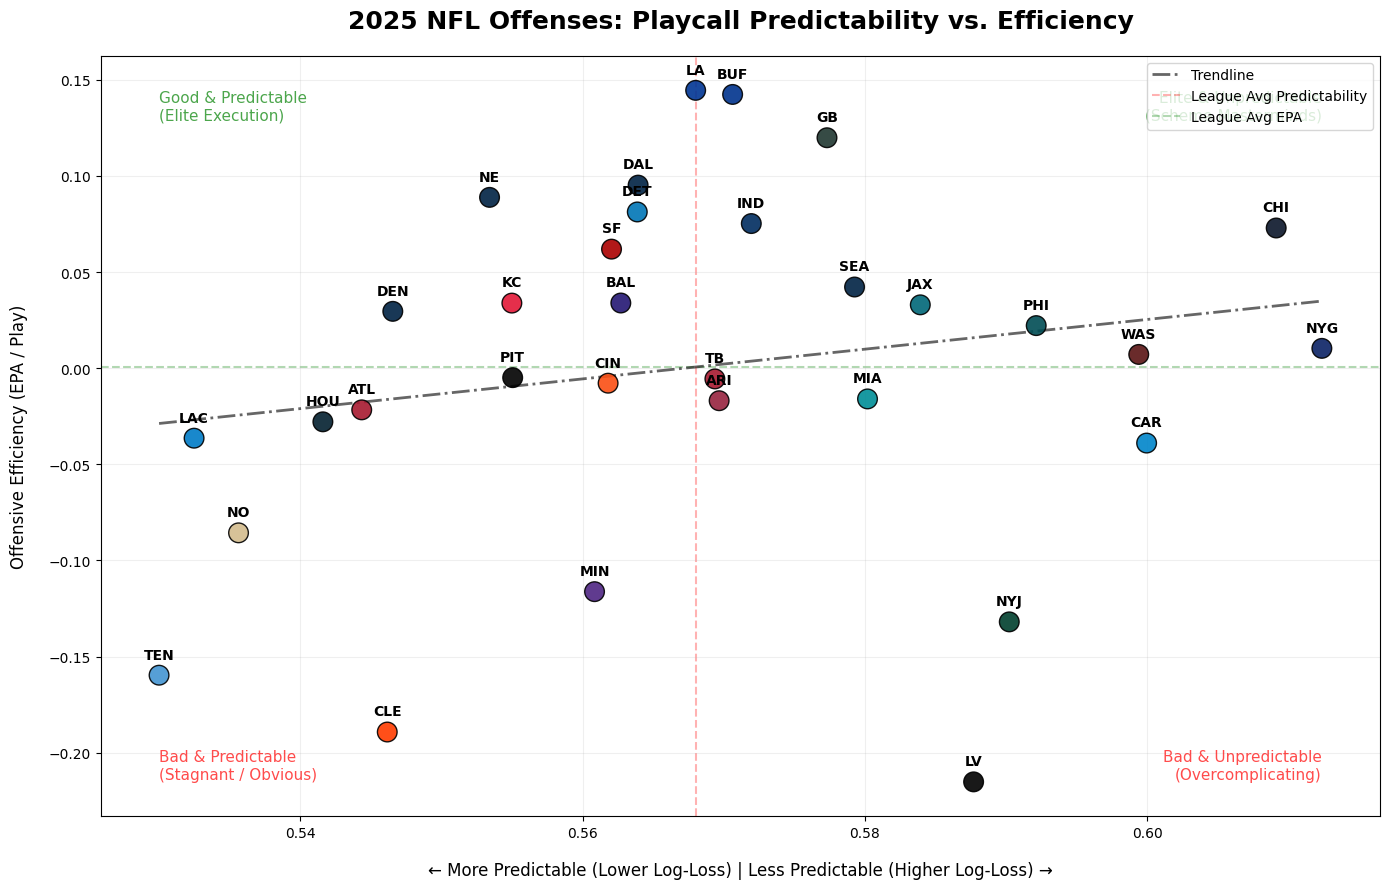

Correlation (r): 0.185


In [65]:
# 1. Calculate average EPA per play for each team in the 2025 dataset
epa_df = test_df.groupby('posteam')['epa'].mean().reset_index()
epa_df.rename(columns={'epa': 'EPA_per_Play'}, inplace=True)

# 2. Merge efficiency with our predictability scores
plot_df = predictability_df.merge(epa_df, left_on='Team', right_on='posteam')

# 3. Load NFL Team Colors and merge them in
teams_data = nfl.load_teams()

# Convert Polars to Pandas if necessary
if not isinstance(teams_data, pd.DataFrame):
    teams_df = teams_data.to_pandas()
else:
    teams_df = teams_data.copy()

plot_df = plot_df.merge(teams_df[['team_abbr', 'team_color']], left_on='Team', right_on='team_abbr', how='left')

# 4. Create the Scatter Plot
plt.figure(figsize=(14, 9))

# Color dots based on actual hex code
plt.scatter(plot_df['Predictability_Score'], plot_df['EPA_per_Play'],
            c=plot_df['team_color'], s=200, alpha=0.9, edgecolors='black', zorder=3)

# Annotate each dot with the team abbreviation
for i, row in plot_df.iterrows():
    plt.annotate(row['Team'],
                 (row['Predictability_Score'], row['EPA_per_Play']),
                 textcoords="offset points", xytext=(0,12), ha='center',
                 fontsize=10, fontweight='bold', zorder=4)

# 5. Calc Regression Line & Add to Graph
m, b = np.polyfit(plot_df['Predictability_Score'], plot_df['EPA_per_Play'], 1)
x_val = np.linspace(plot_df['Predictability_Score'].min(), plot_df['Predictability_Score'].max(), 100)
plt.plot(x_val, m*x_val + b, color='black', linestyle='-.', linewidth=2, alpha=0.6,
         label='Trendline', zorder=2)

# 6. League Average Lines
avg_predictability = plot_df['Predictability_Score'].mean()
avg_epa = plot_df['EPA_per_Play'].mean()

plt.axvline(avg_predictability, color='red', linestyle='--', alpha=0.3, label='League Avg Predictability', zorder=1)
plt.axhline(avg_epa, color='green', linestyle='--', alpha=0.3, label='League Avg EPA', zorder=1)

# 7. Graph Format
plt.title('2025 NFL Offenses: Playcall Predictability vs. Efficiency', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('← More Predictable (Lower Log-Loss) | Less Predictable (Higher Log-Loss) →', fontsize=12, labelpad=15)
plt.ylabel('Offensive Efficiency (EPA / Play)', fontsize=12, labelpad=15)

# Quadrant Text Anchors
plt.text(plot_df['Predictability_Score'].min(), plot_df['EPA_per_Play'].max(),
         'Good & Predictable\n(Elite Execution)',
         fontsize=11, color='green', alpha=0.7, ha='left', va='top')

plt.text(plot_df['Predictability_Score'].max(), plot_df['EPA_per_Play'].max(),
         'Elite & Unpredictable\n(Scheme Masterminds)',
         fontsize=11, color='green', alpha=0.7, ha='right', va='top')

plt.text(plot_df['Predictability_Score'].min(), plot_df['EPA_per_Play'].min(),
         'Bad & Predictable\n(Stagnant / Obvious)',
         fontsize=11, color='red', alpha=0.7, ha='left', va='bottom')

plt.text(plot_df['Predictability_Score'].max(), plot_df['EPA_per_Play'].min(),
         'Bad & Unpredictable\n(Overcomplicating)',
         fontsize=11, color='red', alpha=0.7, ha='right', va='bottom')

plt.grid(True, alpha=0.2, zorder=0)
plt.legend()
plt.tight_layout()
plt.show()

# 8. Correlation Calc
correlation = plot_df['Predictability_Score'].corr(plot_df['EPA_per_Play'])
print(f"Correlation (r): {correlation:.3f}")